In [3]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market import Market

In [4]:
from joblib import dump, load

market = load(project_root / "results/market_simulation_dyn_beta.joblib")

In [29]:
import src.utils
from importlib import reload
reload(src.utils)
from src.utils import make_scenario, generate_scenarios

In [7]:
scenario, r_m, last_r, last_vol, lasts = make_scenario(100, "weekly", market, return_last=True)

In [8]:
N = 20 # n_assets
T = 10 # n_timeperiods - the amount the model sees ahead
K = 100 # n_scenarios

freq = 'weekly'
rf = market.rf

n_steps = 52
n_simulations = 50

trade_cost = 0.003

In [10]:
scenarios = generate_scenarios(K, T, N, 'weekly', market)

## MPC

In [30]:
import src.MPCController
from importlib import reload
reload(src.MPCController)
from src.MPCController import MPCController

from src.utils import simulate_target_weight_portfolio

In [31]:
controller = MPCController(K, T, N, risk_free=rf, risk=0.2, trade=trade_cost, risk_type='variance')

In [32]:
controller.is_QP_and_DPP()

(True, True)

In [15]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(5), desc='Outer'):
    for j in tqdm(range(10), desc='Inner', leave=False):
        time.sleep(.2)

Outer:   0%|          | 0/5 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

In [35]:
import src
from importlib import reload
reload(src.Market_v2)
from src.Market_v2 import Market


market = Market(20, 5, None)

In [40]:
lasts.iloc[i-1]

0     0.003175
1     0.006714
2    -0.006237
3    -0.000069
4    -0.002505
5     0.005381
6    -0.006374
7     0.003847
8     0.012204
9    -0.007462
10   -0.011382
11    0.007416
12   -0.005406
13    0.003544
14   -0.008072
15   -0.004804
16   -0.015405
17    0.000124
18   -0.005774
19    0.000961
Name: 2024-12-27 00:00:00, dtype: float64

In [ ]:
from tqdm.notebook import tqdm

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    x_init = [100] + [0 for _ in range(N)]

    MPC_sims = np.zeros((n_simulations, n_steps+1, N+1)) # + initial value
    market_sims = np.zeros((n_simulations, n_steps+1))
    eq_sims = np.zeros((n_simulations, n_steps+1, N+1))

    for i in tqdm(range(n_simulations), desc='Simulations'):
        # NOTE: lasts are always daily for market, and market return is too
        actual_traj, market_return, last_r_m, last_vol, lasts =\
            make_scenario(n_steps, freq, market, return_last=True)

        MPC_sim = [x_init]

        for step in tqdm(range(n_steps), desc=f'simulation {i+1}', leave=False):
            if step == 0:
                scenarios = generate_scenarios(K ,T, N, freq, market)#, burn=500)
            else:
                scenarios = generate_scenarios(K ,T, N, freq, market, initial_returns=lasts.iloc[step-1])
                                               #burn=0, 
                                                #initial_value=last_r_m.iloc[step-1], 
                                                #initial_vol=last_vol.iloc[step-1])
            
            controller.update_parameters(scenarios, MPC_sim[-1])
            stats = controller.solve()
            u0 = controller.control()

            x_next = (MPC_sim[-1] + u0) * np.hstack([1+rf, 1+actual_traj.iloc[step]])

            MPC_sim.append(x_next)

        MPC_sims[i] = np.array(MPC_sim)
        market_sims[i] = np.exp(np.concat([[0], market_return])).cumprod() * 100
        eq_sims[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, actual_traj.T, trading_cost=trade_cost)

Simulations:   0%|          | 0/50 [00:00<?, ?it/s]

simulation 1:   0%|          | 0/52 [00:00<?, ?it/s]

ValueError: could not broadcast input array from shape (52,20) into shape (20,)

## Results

In [130]:
from joblib import dump
dump(MPC_sims, project_root / "results/dyn_beta/MPC_sims.joblib")
dump(market_sims, project_root / "results/dyn_beta/market_sims.joblib")
dump(eq_sims, project_root / "results/dyn_beta/eq_sims.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\dyn_beta\\eq_sims.joblib']

In [59]:
from joblib import load
MPC_sims = load(project_root / "results/dyn_beta/MPC_sims.joblib")
market_sims = load(project_root / "results/dyn_beta/market_sims.joblib")
eq_sims = load(project_root / "results/dyn_beta/eq_sims.joblib")

In [131]:
market_sims = pd.DataFrame(market_sims)
MPC_sims = pd.DataFrame(MPC_sims.sum(axis=2))
eq_sims = pd.DataFrame(eq_sims.sum(axis=2))

In [132]:
import src.portfolio_analysis
from importlib import reload
reload(src.portfolio_analysis)

<module 'src.portfolio_analysis' from 'C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\src\\portfolio_analysis.py'>

In [133]:
from src.portfolio_analysis import plot_simulations, compute_returns, compute_metrics

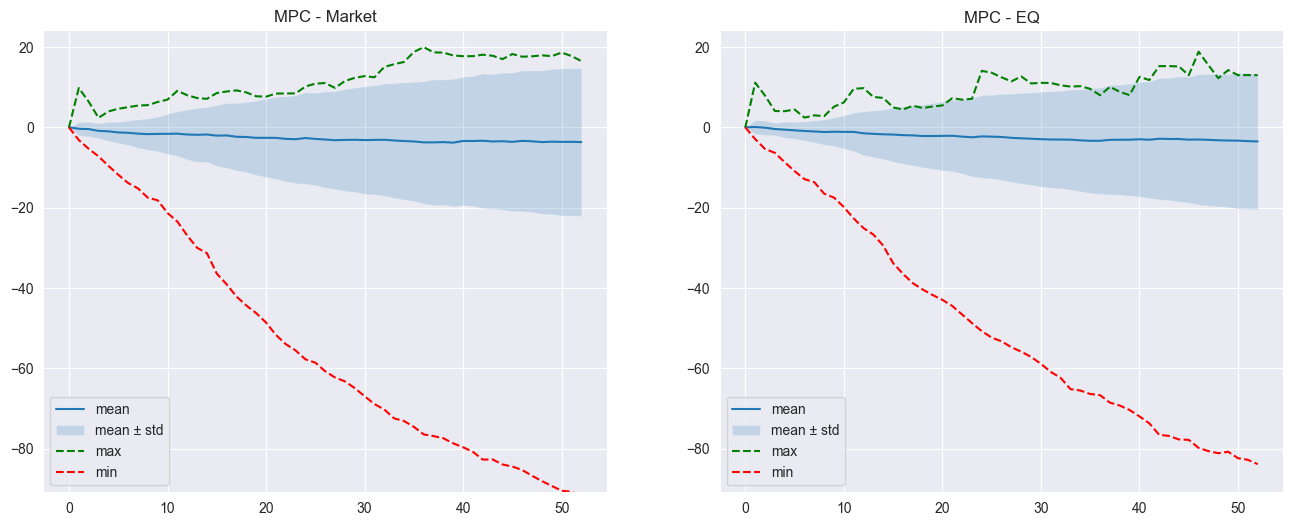

In [134]:
plot_simulations([MPC_sims - market_sims, MPC_sims - eq_sims], labels=["MPC - Market", 'MPC - EQ'])

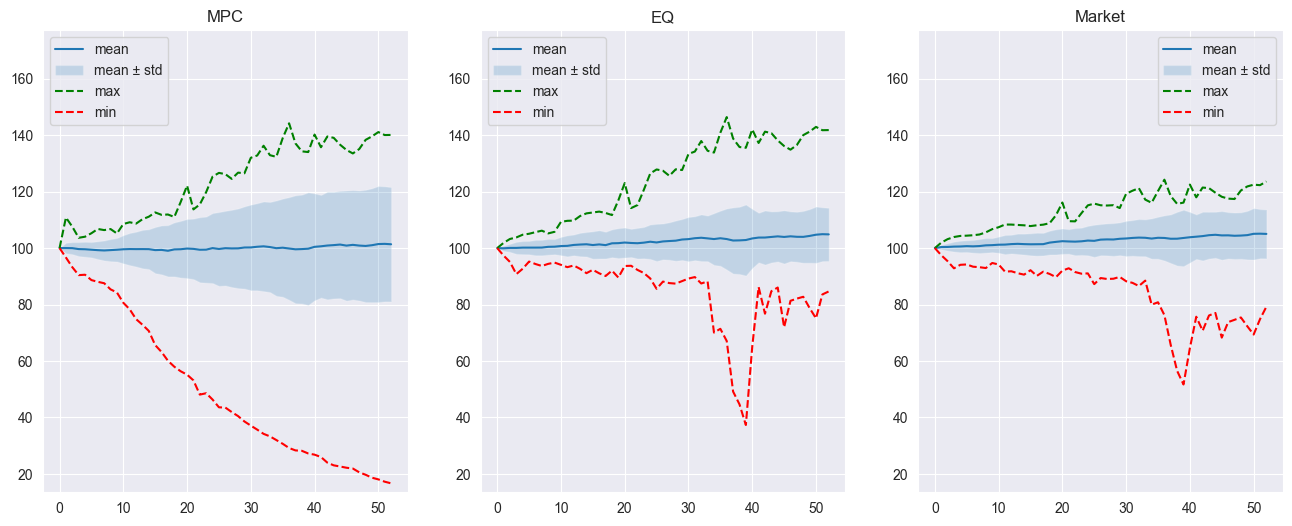

In [135]:
plot_simulations([MPC_sims, eq_sims, market_sims], labels=['MPC', 'EQ', 'Market'])

In [136]:
returns = compute_returns([MPC_sims, eq_sims, market_sims], names=['MPC', 'EQ', 'Market'])

In [137]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

mpc_capm = []
eq_capm = []

for col in returns['MPC'].columns:
    lm = linear_model.OLS(returns['MPC'][col], sm.add_constant(returns['Market'][col])).fit()
    mpc_capm.append(lm)

    lm = linear_model.OLS(returns['EQ'][col], sm.add_constant(returns['Market'][col])).fit()
    eq_capm.append(lm)

In [138]:
capm_coeffs = pd.DataFrame(index=['MPC alpha', 'MPC beta', 'EQ alpha', 'EQ beta'])

for i in range(n_simulations):
    capm_coeffs[i] = np.hstack([mpc_capm[i].params.values, eq_capm[i].params.values])

In [139]:
from src.portfolio_analysis import conf_int_high, conf_int_low, conf_int_p

In [140]:
capm_summary = capm_coeffs.agg(['mean', 'std', 'sem', conf_int_low, conf_int_high, conf_int_p], axis=1)
capm_summary # NOTE: betas are with mean (2 sided), alphas with 0 (greater) (so betas p are not very meaningful)

,mean,std,sem,conf_int_low,conf_int_high,conf_int_p
MPC alpha,-0.001134,0.007062,0.000999,-0.002808,inf,0.869097
MPC beta,0.972710,0.279031,0.039461,0.893410,1.052009,1.000000
EQ alpha,0.000198,0.001633,0.000231,-0.000189,inf,0.197970
EQ beta,0.980583,0.183503,0.025951,0.928432,1.032734,1.000000


In [141]:
metrics = compute_metrics(returns, rf)
metrics

,MPC,EQ,Market
mean of mean returns,-0.000247,0.001076,0.000979
std of mean returns,0.006991,0.001745,0.001534
se of mean returns,0.000989,0.000247,0.000217
ci_low of mean returns,-0.002234,0.000580,0.000543
ci high of mean returns,0.001740,0.001572,0.001415
mean of sharpe ratios,0.015021,0.074391,0.111491
std of sharpe ratios,0.330903,0.117192,0.160060
se of sharpe ratios,0.046797,0.016573,0.022636
ci_low of sharpe ratios,-0.079021,0.041085,0.066003
ci high of sharpe ratios,0.109063,0.107696,0.156980
